<div style="background-color: RGB(93, 173, 226);" >
    <center> 
        <h1 style="margin: auto; padding: 20px; color:#fff; ">  Anticipez les besoins en consommation de bâtiments </h1> 
    </center>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> II - Prédiction des émissions de C02 </h3>
</div>

In [1]:
#pip install shap

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Importation des utilitaires </h4>
</div>

In [45]:
import polars as pl
import numpy as np
import pandas as pd
import statsmodels.api as sm
import shap

from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR

import matplotlib.pyplot as plt

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> chargement des données clean </h4>
</div>

In [3]:
df = pl.read_csv("data_batiment_2016_clean.csv")
df.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,1927,1.0,12.0,88434.0,81.699997,7226362.5,2.83,60.0,0.54606,0.277302
1,2,1996,1.0,11.0,103566.0,94.800003,8.387933e6,2.86,61.0,0.297569,0.23031
2,3,1969,1.0,2.0,47237.0,96.0,2.6152e6,2.19,43.0,0.405656,0.223646
3,5,1926,1.0,10.0,61320.0,110.800003,6.794584e6,4.67,56.0,0.407519,0.325913
4,8,1980,1.0,18.0,175580.0,114.800003,1.4172606e7,2.88,75.0,0.290734,0.23249


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.1 - Régression Linéaire avec statsmodels </h4>
</div>

In [4]:
# Séparation des variables explicatives (X) et de la variable cible (Y)
X = df.select(pl.exclude(["GHGEmissionsIntensity", "OSEBuildingID", "ENERGYSTARScore"]))
Y = df.select("GHGEmissionsIntensity")

In [5]:
# Ajout d'une constante pour le modèle OLS
X = sm.add_constant(X.to_pandas())

In [6]:
# création du modèle OLS
linear_model = sm.OLS(Y, X).fit()

In [7]:
# Résumé du modèle
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     304.6
Date:                Thu, 22 May 2025   Prob (F-statistic):          1.72e-319
Time:                        18:23:09   Log-Likelihood:                -1720.3
No. Observations:                1381   AIC:                             3461.
Df Residuals:                    1371   BIC:                             3513.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            6.2486      1.455      4.293      0.000       3.394       9.104
                              4.642e-05   5.86e-05      0.792      0.428   -6.85e-05       0.000
YearBuilt                       -0.0019      0.001     -2.549      0.011      -0.003      -0.000
NumberofBuildings                0.2114      0.227      0.930      0.352      -0.234       0.657
NumberofFloors                   0.0056      0.010      0.550      0.582      -0.014       0.025
PropertyGFATotal              6.389e-07   4.46e-07      1.433      0.152   -2.35e-07    1.51e-06
SiteEUI(kBtu/sf)                 0.0183      0.001     30.624      0.000       0.017       0.020
SiteEnergyUse(kBtu)           4.029e-09   1.12e-08      0.358      0.720    -1.8e-08    2.61e-08
Electricity_Proportion(kBtu)    -3.8477      0.139    -27.690      0.000      -4.120      -3.575
SteamUse_Proportion(kBtu)       -2.8387      0.224    -12.696      0.000      -3.277      -2.400
==============================================================================
Omnibus:                      311.762   Durbin-Watson:                   1.927
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12177.125
Skew:                           0.149   Prob(JB):                         0.00
Kurtosis:                      17.544   Cond. No.                     3.10e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.1e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Amélioration

In [8]:
# Ajout de la consommation moyenne d'énergie par étage
#df = df.with_columns(
#    (pl.col("SiteEnergyUse(kBtu)") / pl.col("NumberofFloors")).alias("EnergyUsePerFloor(kBtu)")
#)
#df.head()

In [9]:
# Nouvelle séparation des variables explicatives (X) et de la variable cible (Y)
#X = df.select(pl.exclude(["GHGEmissionsIntensity", "OSEBuildingID", "ENERGYSTARScore"]))
#Y = df.select("GHGEmissionsIntensity")

In [10]:
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Y_scaled = scaler.fit_transform(Y.reshape(-1, 1))

In [11]:
# Reshape Y pour éviter l'avertissement
Y = Y.to_numpy().ravel()

In [12]:
# Création du modèle OLS avec les données normalisées
linear_model_2 = sm.OLS(Y, X_scaled).fit()

In [13]:
# Résumé du modèle linéaire
print("Modèle OLS avec données normalisées :")
print("===================================")
linear_model_2.summary()

Modèle OLS avec données normalisées :


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1967: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.369
Model:                            OLS   Adj. R-squared (uncentered):              0.365
Method:                 Least Squares   F-statistic:                              89.20
Date:                Thu, 22 May 2025   Prob (F-statistic):                   1.27e-130
Time:                        18:23:09   Log-Likelihood:                         -2568.7
No. Observations:                1381   AIC:                                      5155.
Df Residuals:                    1372   BIC:                                      5203.
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0          0        nan        nan           0           0
x1             0.0200      0.047      0.429      0.668      -0.072       0.112
x2            -0.0624      0.045     -1.379      0.168      -0.151       0.026
x3             0.0212      0.042      0.504      0.615      -0.061       0.104
x4             0.0151      0.051      0.298      0.766      -0.085       0.115
x5             0.0463      0.060      0.776      0.438      -0.071       0.163
x6             0.9186      0.055     16.573      0.000       0.810       1.027
x7             0.0136      0.070      0.194      0.846      -0.124       0.151
x8            -0.7933      0.053    -14.985      0.000      -0.897      -0.689
x9            -0.3867      0.056     -6.871      0.000      -0.497      -0.276
==============================================================================
Omnibus:                      311.762   Durbin-Watson:                   0.564
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12177.125
Skew:                           0.149   Prob(JB):                         0.00
Kurtosis:                      17.544   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [14]:
# Calculer la matrice de corrélation
corr_matrix = X.corr()

# Identifier les paires de colonnes avec une corrélation élevée (> 0.7)
high_corr = [(col1, col2) for col1 in corr_matrix.columns for col2 in corr_matrix.columns 
             if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > 0.7]
print(f"Paires de colonnes fortement corrélées : {high_corr}")

Paires de colonnes fortement corrélées : []


##### NOTES : Le modèle linéaire n'est pas concluant essayons en d'autres.

#### Séparation des données en ensembles d'entraînement et de test

In [15]:
# 20% des données sont utilisées pour le test, et 80% pour l'entraînement et séparation reproductible à 42
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
# Ajustement des données d'entraînement
X_train_scaled = scaler.fit_transform(X_train)
# Normalisation des données de test
X_test_scaled = scaler.transform(X_test)

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.2 - Modèle de régression par boosting (GradientBoostingRegressor) </h4>
</div>

In [17]:
# Création du modèle de régression par boosting (Utilisation de GradientBoostingRegressor)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
# Entraînement du modèle
gb_model.fit(X_train_scaled, y_train)
# Prédictions
gb_model_pred = gb_model.predict(X_test_scaled)

In [18]:
# Evaluation du modèle GradientBoostingRegressor
gb_model_r2 = r2_score(y_test, gb_model_pred)
gb_model_mae = mean_absolute_error(y_test, gb_model_pred)
gb_model_rmse = mean_squared_error(y_test, gb_model_pred)

# Validation croisée
gb_model_cv = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("GradientBoostingRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {gb_model_r2}")
print(f"MAE moyen : {gb_model_mae}")
print(f"RMSE moyen : {gb_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-gb_model_cv.mean()}")

GradientBoostingRegressor Evaluation :
R2 Score : 0.6582554507613927
MAE moyen : 0.3456659710189178
RMSE moyen : 0.503733315449517
Validation croisée :
MSE moyen : 0.6713282602989288


##### NOTES :

- **R² (Coefficient de Détermination)** : Le modèle explique environ 66% de la variance des données cibles. Cela indique que le modèle capture une partie significative des relations entre les variables explicatives et la cible, mais il reste encore une marge d'amélioration.
- **MAE (Mean Absolute Error)** : En moyenne, les prédictions du modèle s'écartent de 0.345 unités de la valeur réelle. Cela peut être considéré comme une erreur modérée, mais cela dépend de l'échelle des données.
- **RMSE (Root Mean Squared Error)** : L'erreur quadratique moyenne (0.503) est relativement faible, ce qui indique que les prédictions sont globalement proches des valeurs réelles.
- **Validation croisée (MSE moyen)** : La moyenne des erreurs quadratiques moyennes sur les plis de validation croisée est légèrement supérieure au RMSE, ce qui montre que le modèle est relativement stable sur des données non vues.
- **RMSE VS MAE** : Le RMSE > MAE, cela montre qu'il existe encore des erreurs importantes dans certaines prédictions.

##### Interprétation :
Le modèle GradientBoostingRegressor est performant, mais il peut encore être amélioré pour mieux capturer les relations dans les données.

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.3 - Modèle SVM </h4>
</div>

In [19]:
# Définition du modèle SVM avec noyau RBF (pour les relations non linéaires)
svm_model = SVR(kernel='rbf')
# Entraînement du modèle SVM
svm_model.fit(X_train_scaled, y_train)
# Prédictions
svm_model_pred = svm_model.predict(X_test_scaled)

In [20]:
# Calcul de la moyenne des scores de validation croisée
#svm_cv_mean_mse = -np.mean(svm_cv_scores)
#svm_cv_rmse = np.sqrt(svm_cv_mean_mse)

# Evaluation du modèle SVM
svm_model_r2 = r2_score(y_test, svm_model_pred)
svm_model_mae = mean_absolute_error(y_test, svm_model_pred)
svm_model_rmse = mean_squared_error(y_test, svm_model_pred)
#svm_model_rmse = mean_squared_error(svm_model_mse)

# Validation croisée avec 5 plis
svm_model_cv = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("SVM Evaluation :")
print("===================================")
print(f"R2 Score : {svm_model_r2}")
print(f"MAE moyen : {svm_model_mae}")
print(f"RMSE moyen : {svm_model_rmse}")
print("==================")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-svm_model_cv.mean()}")

SVM Evaluation :
R2 Score : 0.7645144693375675
MAE moyen : 0.2494095099989758
RMSE moyen : 0.34710694688550464
Validation croisée :
MSE moyen : 0.6942738831751879


##### NOTES :

- **R² (Coefficient de Détermination)** : Le modèle explique environ 76% de la variance des données cibles. Cela représente une amélioration par rapport au GradientBoostingRegressor (R² = 0.61), indiquant que le modèle SVM capture mieux les relations entre les variables explicatives et la cible.
- **MAE (Mean Absolute Error)** :  En moyenne, les prédictions du modèle s'écartent de 0.271 unités de la valeur réelle. Cela montre que le modèle est plus précis que le GradientBoostingRegressor (MAE = 0.327).
- **RMSE (Root Mean Squared Error)** : L'erreur quadratique moyenne est également plus faible que celle du GradientBoostingRegressor (RMSE = 0.588), ce qui confirme que les prédictions du modèle SVM sont globalement plus proches des valeurs réelles.
- **Validation croisée (MSE moyen)** : La moyenne des erreurs quadratiques moyennes sur les plis de validation croisée est légèrement inférieure à celle du GradientBoostingRegressor (MSE moyen = 0.689), ce qui montre que le modèle SVM est plus stable sur des données non vues.
- **RMSE VS MAE** : Le RMSE > MAE, cela montre qu'il existe encore des erreurs importantes dans certaines prédictions.

##### Interprétation :
Le modèle SVM offre de meilleures performances que le GradientBoostingRegressor, avec un R² plus élevé et des erreurs (MAE et RMSE) plus faibles.


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.4 -Modèle andom Forest </h4>
</div>

In [21]:
#Définition du modèle random forest
rf_model =  RandomForestRegressor(random_state=42)
# Entraînement du modèle
rf_model.fit(X_train_scaled, y_train)
# Prédictions
rf_model_pred = rf_model.predict(X_test_scaled)


In [22]:
# Evaluation du modèle RandomForestRegressor
rf_model_r2 = r2_score(y_test, rf_model_pred)
rf_model_mae = mean_absolute_error(y_test, rf_model_pred)
rf_model_rmse = mean_squared_error(y_test, rf_model_pred)

# Validation croisée
rf_model_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Affichage des résultats
print("RandomForestRegressor Evaluation :")
print("===================================")
print(f"R2 Score : {rf_model_r2}")
print(f"MAE moyen : {rf_model_mae}")
print(f"RMSE moyen : {rf_model_rmse}")
print("===============")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-rf_model_cv.mean()}")

RandomForestRegressor Evaluation :
R2 Score : 0.671061594973419
MAE moyen : 0.3150159566787003
RMSE moyen : 0.48485698956101064
Validation croisée :
MSE moyen : 0.740538421773881


##### NOTES :

- **R² (Coefficient de Détermination)** : Le modèle explique environ 63% de la variance des données cibles. Cela est légèrement inférieur au SVM (R² = 0.636), mais reste comparable.

- **MAE (Mean Absolute Error)** :  En moyenne, les prédictions du modèle s'écartent de 0.302 unités de la valeur réelle. Cela est légèrement moins précis que le SVM (MAE = 0.271).

- **RMSE (Root Mean Squared Error)** : L'erreur quadratique moyenne (0.558) est légèrement supérieure à celle du SVM (RMSE = 0.549), ce qui indique que les prédictions du modèle RandomForestRegressor sont globalement un peu moins proches des valeurs réelles.

- **Validation croisée (MSE moyen)** : La moyenne des erreurs quadratiques moyennes sur les plis de validation croisée (0.734) est supérieure à celle du SVM (MSE moyen = 0.641), ce qui montre que le modèle RandomForestRegressor est un peu moins stable sur des données non vues.

- **RMSE VS MAE** : Le RMSE > MAE, cela montre qu'il existe encore des erreurs importantes dans certaines prédictions.

##### Interprétation :
Le modèle RandomForestRegressor offre des performances comparables au SVM, mais il est légèrement moins performant en termes de précision (MAE et RMSE) et de stabilité (MSE moyen).

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.5 - Comparaison des modèles </h4>
</div>

In [23]:
# Création d'un DataFrame pour stocker les résultats
md_results = {
    'Model': ['Gradient Boosting', 'SVM', 'Random Forest'],
    'R2 Score': [gb_model_r2, svm_model_r2, rf_model_r2],
    'MAE': [gb_model_mae, svm_model_mae, rf_model_mae],
    'RMSE': [gb_model_rmse, svm_model_rmse, rf_model_rmse],
    'MSE' : [-gb_model_cv.mean(), -svm_model_cv.mean(), -rf_model_cv.mean()]
}
md_results_df = pl.DataFrame(md_results)
# Affichage des résultats
print("Comparaison des modèles :")
print("===================================")
print(md_results_df)

Comparaison des modèles :
shape: (3, 5)
┌───────────────────┬──────────┬──────────┬──────────┬──────────┐
│ Model             ┆ R2 Score ┆ MAE      ┆ RMSE     ┆ MSE      │
│ ---               ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str               ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════════╪══════════╪══════════╪══════════╪══════════╡
│ Gradient Boosting ┆ 0.658255 ┆ 0.345666 ┆ 0.503733 ┆ 0.671328 │
│ SVM               ┆ 0.764514 ┆ 0.24941  ┆ 0.347107 ┆ 0.694274 │
│ Random Forest     ┆ 0.671062 ┆ 0.315016 ┆ 0.484857 ┆ 0.740538 │
└───────────────────┴──────────┴──────────┴──────────┴──────────┘


##### Conclusion et choix :

Le modèle SVM semble être le plus robuste parmi les trois modèles comparés, pour les raisons suivantes :

1. R² Score (Coefficient de Détermination) :
SVM a le score R² le plus élevé (0.7645), ce qui indique qu'il explique mieux la variance des données cibles par rapport aux autres modèles.

2. MAE (Mean Absolute Error) :
SVM a la plus faible erreur absolue moyenne (0.2494), ce qui signifie que ses prédictions sont, en moyenne, les plus proches des valeurs réelles.

3. RMSE (Root Mean Squared Error) :
SVM a également le plus faible RMSE (0.3471), ce qui montre qu'il gère mieux les grandes erreurs par rapport aux autres modèles.

4. MSE (Mean Squared Error) :
Bien que le SVM ait un MSE légèrement supérieur à celui du Gradient Boosting (0.6943 contre 0.6713), la différence est minime et n'affecte pas sa robustesse globale.

Conclusion :
Le SVM est le modèle le plus robuste, car il offre les meilleures performances globales en termes de précision (R², MAE, RMSE). Il est donc recommandé de l'utiliser pour cette tâche.

In [38]:
# Définitio des hyperparametre a testr du SVM
param_grid = {
    'C': [0.1, 1, 10, 100], # Pénalité de régularisation
    'epsilon': [0.01, 0.1, 0.5, 1], # Tolérance pour la marge
    'gamma': ['scale'], #[0.01, 0.1, 1, 10], # Coefficient du noyau
    #'degree': [2, 3, 4], # Degré du polynôme (pour le noyau polynomial)
    #'shrinking': [True], # Activer la réduction de la taille du noyau
    'kernel': ['rbf'] # Type de noyau
}

# Recherche des hyperparamètres optimaux
svm_grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='neg_mean_squared_error')
# Entraînement du modèle avec recherche des hyperparamètres
svm_grid_search.fit(X_train_scaled, y_train)

# Meilleurs hyperparamètres
best_params = svm_grid_search.best_params_
# Meilleur score MSE
best_score = -svm_grid_search.best_score_
print("Meilleurs hyperparamètres :")
print("===================================")
print(best_params)
print("Meilleur score (MSE)")
print("===================================")
print(best_score)

Meilleurs hyperparamètres :
{'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur score (MSE)
0.6942738831751879


In [39]:
# création du modèle SVM avec les meilleurs hyperparamètres
svm_model_best = SVR(**best_params)
# Entraînement du modèle SVM avec les meilleurs hyperparamètres
svm_model_best.fit(X_train_scaled, y_train)
# Prédictions
svm_model_best_pred = svm_model_best.predict(X_test_scaled)

In [40]:
# Evaluation du modèle SVM avec les meilleurs hyperparamètres
svm_model_best_r2 = r2_score(y_test, svm_model_best_pred)
svm_model_best_mae = mean_absolute_error(y_test, svm_model_best_pred)
svm_model_best_rmse = mean_squared_error(y_test, svm_model_best_pred)
# Validation croisée avec 5 plis
svm_model_best_cv = cross_val_score(svm_model_best, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
# Affichage des résultats
print("SVM avec meilleurs hyperparamètres Evaluation :")
print("===================================")
print(f"R2 Score : {svm_model_best_r2}")
print(f"MAE moyen : {svm_model_best_mae}")
print(f"RMSE moyen : {svm_model_best_rmse}")
print("==================")
print("Validation croisée :")
print("===================================")
print(f"MSE moyen : {-svm_model_best_cv.mean()}")

SVM avec meilleurs hyperparamètres Evaluation :
R2 Score : 0.7645144693375675
MAE moyen : 0.2494095099989758
RMSE moyen : 0.34710694688550464
Validation croisée :
MSE moyen : 0.6942738831751879


##### Notes : Pas d'amélioration du MSE pour le moment, nous devons encore trvailler les hyperparametres.

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.5 - Analyse de l'importance des caractéristiques </h4>
</div>

In [56]:
# Calcul de l'importance par permutation
result = permutation_importance(svm_model_best, X_test_scaled, y_test)
importances = result.importances_mean
feature_names = X.columns

# Tableau lisible
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Importance des caractéristiques (permutation_importance, SVM RBF) :")
print(importance_df)

Importance des caractéristiques (permutation_importance, SVM RBF) :
                        Feature  Importance
8  Electricity_Proportion(kBtu)    0.692226
6              SiteEUI(kBtu/sf)    0.489650
9     SteamUse_Proportion(kBtu)    0.145433
7           SiteEnergyUse(kBtu)    0.139697
5              PropertyGFATotal    0.111782
1                                  0.025508
2                     YearBuilt    0.017451
0                         const    0.000000
3             NumberofBuildings   -0.021348
4                NumberofFloors   -0.021852


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.6 - Représentez graphiquement les importances</h4>
</div>

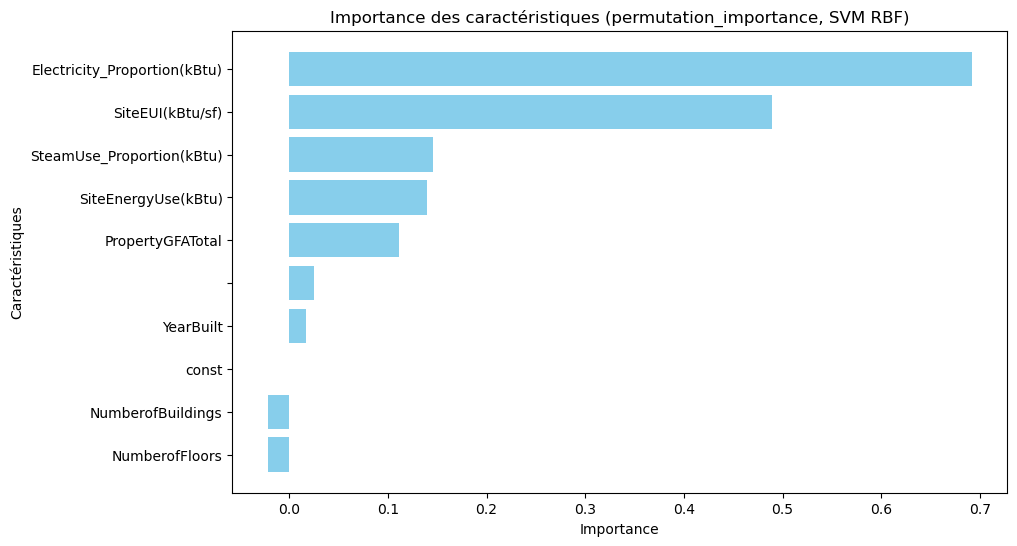

In [58]:
# Diagramme à barres
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Caractéristiques")
plt.title("Importance des caractéristiques (permutation_importance, SVM RBF)")
plt.gca().invert_yaxis()
plt.show()

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.7 - Analyse avancée avec SHAP </h4>
</div>

In [60]:
# Création de l'explainer KernelExplainer pour SVM RBF
explainer = shap.KernelExplainer(svm_model_best.predict, X_train_scaled[:200])  # Utilise un sous-échantillon pour accélérer
shap_values = explainer.shap_values(X_test_scaled[:200])  # Calcul sur un sous-échantillon pour la vitesse

# Calcul de l'importance moyenne absolue de chaque caractéristique
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_names = X.columns

# Tableau lisible
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP value|': mean_abs_shap
}).sort_values(by='Mean |SHAP value|', ascending=False)

print("Importance des caractéristiques (SHAP, SVM RBF) :")
print(shap_importance_df)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

Importance des caractéristiques (SHAP, SVM RBF) :
                        Feature  Mean |SHAP value|
8  Electricity_Proportion(kBtu)           0.486872
6              SiteEUI(kBtu/sf)           0.455271
7           SiteEnergyUse(kBtu)           0.251046
9     SteamUse_Proportion(kBtu)           0.227133
5              PropertyGFATotal           0.202969
4                NumberofFloors           0.033502
2                     YearBuilt           0.032325
1                                         0.027246
3             NumberofBuildings           0.004908
0                         const           0.000000


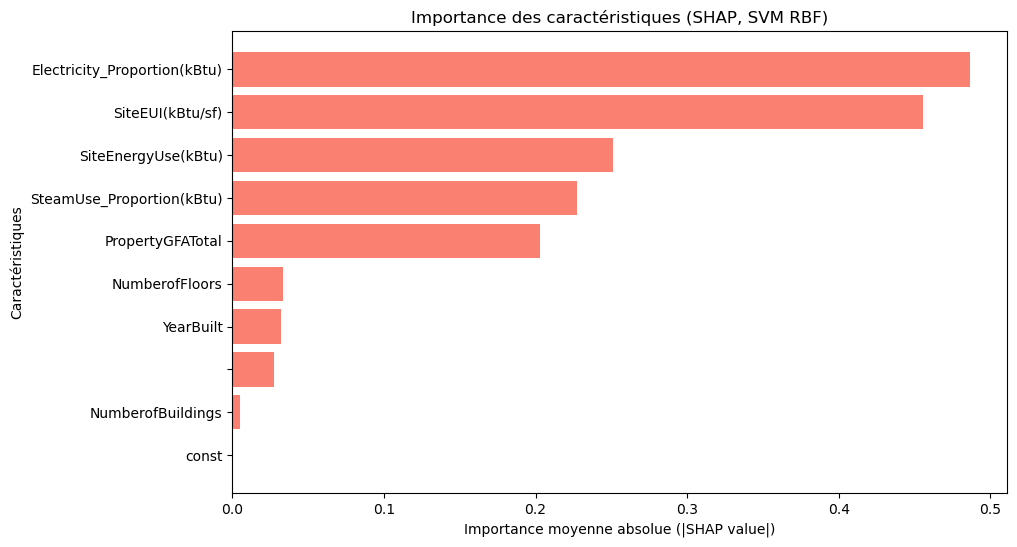

In [61]:
# Diagramme à barres
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['Feature'], shap_importance_df['Mean |SHAP value|'], color='salmon')
plt.xlabel("Importance moyenne absolue (|SHAP value|)")
plt.ylabel("Caractéristiques")
plt.title("Importance des caractéristiques (SHAP, SVM RBF)")
plt.gca().invert_yaxis()
plt.show()

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> II.8 - Analyser de l'influence de ENERGYSTARScore </h4>
</div>

In [72]:
# Inclure ENERGYSTARScore dans les variables explicatives
X_include_ENERGYSTARScore = df.select(pl.exclude(["GHGEmissionsIntensity", "OSEBuildingID"]))
X_include_ENERGYSTARScore.head()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,1927,1.0,12.0,88434.0,81.699997,7226362.5,60.0,0.54606,0.277302
1,1996,1.0,11.0,103566.0,94.800003,8.387933e6,61.0,0.297569,0.23031
2,1969,1.0,2.0,47237.0,96.0,2.6152e6,43.0,0.405656,0.223646
3,1926,1.0,10.0,61320.0,110.800003,6.794584e6,56.0,0.407519,0.325913
4,1980,1.0,18.0,175580.0,114.800003,1.4172606e7,75.0,0.290734,0.23249


In [73]:
# Imputation des valeurs manquantes de ENERGYSTARScore par la moyenne
X_include_ENERGYSTARScore = X_include_ENERGYSTARScore.with_columns(
    pl.col("ENERGYSTARScore").fill_null(pl.col("ENERGYSTARScore").mean())
)
# 20% des données sont utilisées pour le test, et 80% pour l'entraînement et séparation reproductible à 42
X_score_train, X_score_test, y_score_train, y_score_test = train_test_split(X_include_ENERGYSTARScore, Y, test_size=0.2, random_state=42)

In [80]:
X_score_train.head()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
544,1966,1.0,1.0,170632.0,3.5,602245.0,98.0,0.545377,0.390587
487,1974,1.0,5.0,102930.0,53.299999,4.750799e6,85.0,0.718177,0.159477
852,1960,1.0,1.0,27338.0,21.299999,581289.0,56.0,0.510536,0.378816
1230,1949,1.0,3.0,23355.0,38.400002,840549.375,77.0,0.647459,0.324047
1248,1970,1.0,2.0,23595.0,34.599998,817409.625,72.0,0.640174,0.345404


In [74]:
# Ajustement des données d'entraînement
X_train_score_scaled = scaler.fit_transform(X_score_train)
# Normalisation des données de test
X_test_score_scaled = scaler.transform(X_score_test)

In [75]:
# Random Forest avec les meilleurs hyperparamètres
# Création du modèle RandomForestRegressor avec les hyperparamètres trouvés par GridSearchCV
svm_model_score_hp = SVR(**best_params)
# Entraînement du modèle
svm_model_score_hp.fit(X_train_score_scaled, y_score_train)
# Prédictions
svm_model_score_hp_pred = svm_model_score_hp.predict(X_test_score_scaled) 

In [82]:
# Création de l'explainer KernelExplainer pour SVM RBF
explainer_STARScore = shap.KernelExplainer(svm_model_score_hp.predict, X_train_score_scaled[:200])  # Utilise un sous-échantillon pour accélérer
shap_values_STARScore= explainer_STARScore.shap_values(X_test_score_scaled[:200])  # Calcul sur un sous-échantillon pour la vitesse

# Calcul de l'importance moyenne absolue de chaque caractéristique
mean_abs_shap_STARScore = np.abs(shap_values_STARScore).mean(axis=0)
feature_names_STARScore = X.columns

# Tableau lisible
shap_importance_STARScore_df = pd.DataFrame({
    'Feature': feature_names_STARScore,
    'Mean |SHAP value|': mean_abs_shap_STARScore
}).sort_values(by='Mean |SHAP value|', ascending=False)

print("Importance des caractéristiques (SHAP, SVM RBF) :")
print(shap_importance_STARScore_df)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

Importance des caractéristiques (SHAP, SVM RBF) :
                        Feature  Mean |SHAP value|
8  Electricity_Proportion(kBtu)           0.481018
5              PropertyGFATotal           0.447285
6              SiteEUI(kBtu/sf)           0.238868
9     SteamUse_Proportion(kBtu)           0.217671
4                NumberofFloors           0.184437
7           SiteEnergyUse(kBtu)           0.033489
1                                         0.032757
3             NumberofBuildings           0.032467
0                         const           0.026080
2                     YearBuilt           0.005208


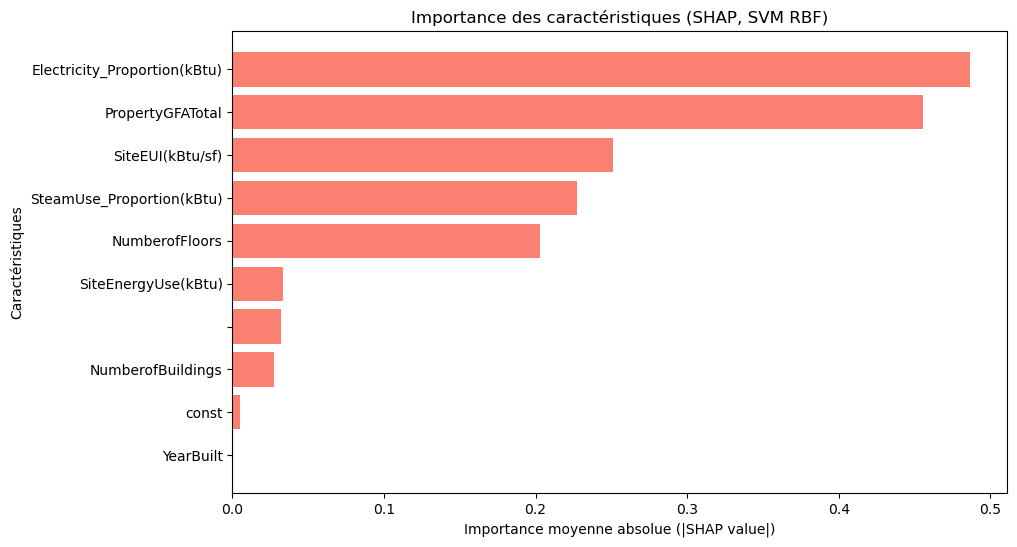

In [84]:
# Diagramme à barres
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_STARScore_df['Feature'], shap_importance_df['Mean |SHAP value|'], color='salmon')
plt.xlabel("Importance moyenne absolue (|SHAP value|)")
plt.ylabel("Caractéristiques")
plt.title("Importance des caractéristiques (SHAP, SVM RBF)")
plt.gca().invert_yaxis()
plt.show()

##### Notes : L'importance de la variable ENERGYSTARScore dans le modèle svm est relativement faible, avec une importance de 0.0115, ce qui la place en 8ᵉ position parmi les 10 variables analysées.